# Python for Scientists — Oude examenvragen: modelantwoorden

## Inhoud
- Examenversie 1 (19/01/2023): splines / FFT / code (std)
- Examenversie 2: optimalisatie vs root finding / interpolatie / kwadratuur
- Examenversie 3 (23–24): optimalisatiefamilies / Heun + adaptief / FFT convolutie
- Examenversie 4 (23–24): eigenwaarden / kwadratuur / PRNG
- Examenversie 5 (24–25): stiff ODE's / least squares / Monte Carlo-integratie

---

# Examenversie 1 (19/01/2023)

## 1) Piecewise polynomial interpolation (PPI)

### (a) Waarom PPI i.p.v. 1 globale interpolatieveelterm?
Globale polynoominterpolatie (zeker met hoge graad) heeft typisch:
- Runge-oscillaties (wild gedrag tussen punten),
- slechte conditionering (Vandermonde),
- geen lokale controle (één punt aanpassen beïnvloedt alles).

PPI (splines) gebruikt lage graad per subinterval: stabieler, lokaal, en je kan gladheid afdwingen.

### (b) Hoeveel vrij te kiezen parameters voor een cubic spline?
Met $n$ knopen heb je $n-1$ kubische stukjes. Elk stukje heeft 4 coëfficiënten, dus:
$$
4(n-1)
$$
onbekenden. Na interpolatie + $C^1$ en $C^2$ continuïteit blijven er exact **2 vrijheidsgraden** over (die je met randvoorwaarden fixeert).

### (c) Welke voorwaarden leggen parameters vast / laten 2 vrij?
- Interpolatie in elk subinterval: $2(n-1)$ voorwaarden (links en rechts eindpunt per stukje).
- Continuïteit van $S'$ in interne knopen: $n-2$ voorwaarden.
- Continuïteit van $S''$ in interne knopen: $n-2$ voorwaarden.

Totaal:
$$
2(n-1)+(n-2)+(n-2)=4n-6
$$
voorwaarden op $4n-4$ onbekenden $\Rightarrow$ 2 vrij.

### (d) 3 manieren om die 2 vrije parameters te kiezen
- **Natural spline**: $S''(x_0)=S''(x_{n-1})=0$
- **Clamped spline**: $S'(x_0)$ en $S'(x_{n-1})$ opgelegd
- **Not-a-knot**: $S'''$ continu in de "one-but-outermost" knopen

---

## 2) FFT

### (a) 3 voorwaarden/assumpties voor FFT op een time series
1. **Uniforme sampling**: constante $\Delta t$.
2. **Eindige, discrete reeks** met $N$ samples (geen gaten/NaN).
3. **Nyquist/aliasing**: samplingfrequentie hoog genoeg om aliasing te vermijden (in praktijk: bandlimiting).

($N$ een macht van 2 is vooral performance, geen harde wiskundige eis.)

### (b) Moet er een geheel aantal periodes in zitten? Wat als niet?
FFT/DFT behandelt je venster impliciet als **periodiek herhaald**. Geen integer aantal periodes $\Rightarrow$ discontinuïteit aan de randen $\Rightarrow$ **spectral leakage** (energie smeert uit over frequenties).
Remedies: windowing, langer meten, segmenteren/averagen.

### (c) Andere datasets dan time series?
Elke data op een **uniform rooster**: ruimtelijke signalen, 2D beelden, 3D volumes, oplossingen van PDE's (spectrale methodes), convoluties, polynoomvermenigvuldiging.

### (d) Waarom zero padding?
- Om **circulaire** convolutie te vermijden en de **lineaire** convolutie te krijgen (geen wrap-around).
- Om naar een "FFT-vriendelijke" lengte te gaan.
- Om frequentiebins fijner te samplen (fijnere representatie; geen nieuwe informatie).

---

## 3) Codevraag (func1 vs func2)

Beide functies berekenen de **(populatie-)standaardafwijking**:
$$
\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^N (x_i-\bar x)^2}
$$

### (a) Wat berekenen ze?
Ze geven $\sigma$ volgens bovenstaande formule (met $1/N$, niet $1/(N-1)$).

### (b) Efficiëntie en nauwkeurigheid
- `func1`: **two-pass** (eerst $\bar x$, dan variantie). Kost ~2 loops, numeriek **stabieler**.
- `func2`: **one-pass** via $E[x^2]-E[x]^2$. Kost 1 loop, maar numeriek **minder stabiel** door catastrophic cancellation als $\mathrm{Var}(x)$ klein is t.o.v. $E[x]^2$.
Conclusie: **func1** is doorgaans nauwkeuriger.

### (c) Nauwkeurigheid nog verbeteren
Gebruik Welford (online variance) of compensated summation.

In [1]:
import numpy as np

def welford_std(xs):
    """Numeriek stabiele berekening van standaardafwijking via Welford's methode."""
    n = 0
    mean = 0.0
    M2 = 0.0
    for x in xs:
        n += 1
        delta = x - mean
        mean += delta / n
        M2 += delta * (x - mean)
    return (M2 / n) ** 0.5

# demo
xs = np.random.normal(size=100000) + 1e8  # groot gemiddelde, kleine variantie
print("welford:", welford_std(xs))
print("numpy  :", xs.std())

welford: 1.001480875044023
numpy  : 1.0014808763892409



# Examenversie 2

## 1) Optimalisatie vs root finding

### (a) Equivalent van bisection (minima)?
**Golden section search**.

### (b) Equivalent van secant (minima)?
**Successive parabolic interpolation** (parabool door 3 punten en neem het minimum).

### (c) Newton vs secant
- Newton: gebruikt $f'(x)$ (en Hessiaan in multi-D) $\Rightarrow$ lokaal vaak **kwadratische** convergentie.
- Secant: vervangt afgeleide door verschilquotiënt $\Rightarrow$ geen afgeleiden, **superlineair** (orde $\approx 1.618$).

### (d) Waarom geen lineaire interpolatie om minimum te vinden?
Een rechte heeft geen intern extremum: minimum ligt op een endpoint. Voor een intern minimum heb je kromminginfo nodig (minstens 3 punten).

### (e) Inverse kwadratische interpolatie (root) vs gewone kwadratische (minimum)

**Het kernverschil**: wat je zoekt bepaalt hoe je de parabool fit.

#### Voor een **minimum** zoeken:
Je wilt weten: "Bij welke $x$ is $f(x)$ het kleinst?"

- Fit een parabool door je punten: $f(x) \approx ax^2 + bx + c$
- Het minimum van deze parabool is bij $x^* = -\frac{b}{2a}$
- Je fit dus **$f$ als functie van $x$**: $f(x) = \ldots$

**Voorbeeld**: Je hebt punten $(x_1, f_1), (x_2, f_2), (x_3, f_3)$
```
   f ↑
     |     •
     |   •   •  ← parabool door deze punten
     |  •     •
     | •   ↓   •  ← minimum hier
     |__________ x
```

#### Voor een **root** zoeken (IQI):
Je wilt weten: "Bij welke $x$ is $f(x) = 0$?"

- Je **draait de as om**: fit $x$ als functie van $f$
- Fit een parabool: $x \approx q(f) = \alpha f^2 + \beta f + \gamma$
- Evalueer deze bij $f=0$: $x^* = q(0) = \gamma$
- Je fit dus **$x$ als functie van $f$**: $x(f) = \ldots$

**Voorbeeld**: Je hebt punten $(f_1, x_1), (f_2, x_2), (f_3, x_3)$
```
   x ↑
     |     •
     |   •   •  ← parabool met f op x-as!
     |  •     •
     | •
   x*|←────────── bij f=0
     |__________ f
        ↑
       f=0
```

**Waarom "inverse"?** 
Normaal: $f$ hangt af van $x$, dus $f = f(x)$  
Inverse: $x$ hangt af van $f$, dus $x = q(f)$ (rollen omgedraaid!)

---

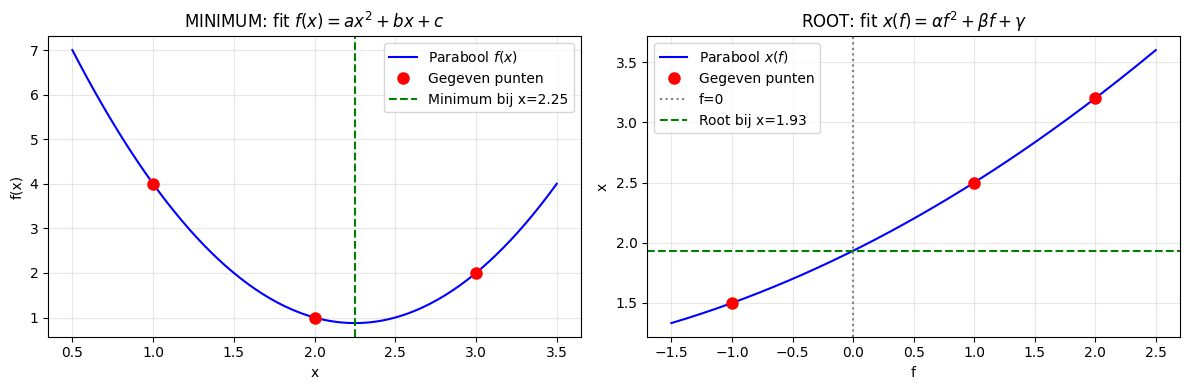

Minimum bij x = 2.250
Root bij x = 1.933


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Demo: verschil tussen gewone en inverse kwadratische interpolatie

# 1) MINIMUM VINDEN: gewone parabool f(x)
plt.close("minimum")
fig, (ax1, ax2) = plt.subplots(1, 2, num="minimum", figsize=(12, 4))

# Data voor minimum
x_pts = np.array([1, 2, 3])
f_pts = np.array([4, 1, 2])  # minimum ligt ergens tussen x=2 en x=3

# Fit parabool f = ax^2 + bx + c
A = np.vstack([x_pts**2, x_pts, np.ones_like(x_pts)]).T
a, b, c = np.linalg.solve(A, f_pts)
x_min = -b / (2*a)

x_plot = np.linspace(0.5, 3.5, 200)
f_plot = a*x_plot**2 + b*x_plot + c

ax1.plot(x_plot, f_plot, 'b-', label='Parabool $f(x)$')
ax1.plot(x_pts, f_pts, 'ro', markersize=8, label='Gegeven punten')
ax1.axvline(x_min, color='green', linestyle='--', label=f'Minimum bij x={x_min:.2f}')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('MINIMUM: fit $f(x) = ax^2 + bx + c$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2) ROOT VINDEN: inverse parabool x(f)
# Data voor root
f_vals = np.array([-1, 1, 2])
x_vals = np.array([1.5, 2.5, 3.2])  # root ligt ergens waar f=0

# Fit parabool x = α f^2 + β f + γ
A_inv = np.vstack([f_vals**2, f_vals, np.ones_like(f_vals)]).T
alpha, beta, gamma = np.linalg.solve(A_inv, x_vals)
x_root = gamma  # bij f=0: x = α(0)^2 + β(0) + γ = γ

f_plot2 = np.linspace(-1.5, 2.5, 200)
x_plot2 = alpha*f_plot2**2 + beta*f_plot2 + gamma

ax2.plot(f_plot2, x_plot2, 'b-', label='Parabool $x(f)$')
ax2.plot(f_vals, x_vals, 'ro', markersize=8, label='Gegeven punten')
ax2.axvline(0, color='gray', linestyle=':', label='f=0')
ax2.axhline(x_root, color='green', linestyle='--', label=f'Root bij x={x_root:.2f}')
ax2.set_xlabel('f')
ax2.set_ylabel('x')
ax2.set_title('ROOT: fit $x(f) = αf^2 + βf + γ$')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Minimum bij x = {x_min:.3f}")
print(f"Root bij x = {x_root:.3f}")

In [3]:
def p(t):
    """Horner-vorm van p(t) = 7t^3 - 3t^2 + 5t - 2"""
    return ((7*t - 3)*t + 5)*t - 2

## 2) Interpolatie (monomial / Lagrange / Newton)

### (a) Computationele kost (typisch) — van snel naar traag
- **Newton**: divided differences $O(n^2)$ setup, evaluatie $O(n)$ (nested/Horner-achtig). **Meest efficiënt in praktijk.**
- **Lagrange**: setup $O(n)$, naïef evaluatie $O(n^2)$ (barycentrisch kan $O(n)$).
- **Monomial basis**: Vandermonde oplossen $O(n^3)$ + slecht geconditioneerd. **Vermijden!**

### (d) Conditionering
Vandermonde (monomial) is vaak zeer ill-conditioned. Newton-vorm is meestal beter. Barycentrische Lagrange is numeriek sterk.

### (e) Eenvoudigste evaluatie in een punt
Newton-vorm (nested form).

### (f) Horner-vorm van $p(t)=7t^3-3t^2+5t-2$
$$
p(t)=((7t-3)t+5)t-2
$$

## 3) Kwadratuur

### (a) Wat is numerieke kwadratuur? Verschil NC / Clenshaw-Curtis / Gauss
- **Newton–Cotes**: vaste (vaak equidistante) knopen, integraal van interpolatiepolynoom.
- **Clenshaw–Curtis**: Chebyshev-knopen, efficiënt/stabiel via cosine-structuur.
- **Gauss**: knopen + gewichten optimaal: met $n$ punten exact tot graad $2n-1$.

### (b) Eerste drie NC regels
- Midpoint:
$$
\int_a^b f(x)\,dx \approx (b-a)\, f\!\left(\frac{a+b}{2}\right)
$$
- Trapezium:
$$
\approx \frac{b-a}{2}\big(f(a)+f(b)\big)
$$
- Simpson:
$$
\approx \frac{b-a}{6}\Big(f(a)+4f(\frac{a+b}{2})+f(b)\Big)
$$

<>:31: SyntaxWarning: invalid escape sequence '\i'
<>:51: SyntaxWarning: invalid escape sequence '\i'
<>:77: SyntaxWarning: invalid escape sequence '\i'
<>:31: SyntaxWarning: invalid escape sequence '\i'
<>:51: SyntaxWarning: invalid escape sequence '\i'
<>:77: SyntaxWarning: invalid escape sequence '\i'
/var/folders/9s/8sbwt7bs0m15y39npx_sphrc0000gn/T/ipykernel_13697/1353514870.py:31: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title('Midpoint: $\int \\approx (b-a) f(\\frac{a+b}{2})$')
/var/folders/9s/8sbwt7bs0m15y39npx_sphrc0000gn/T/ipykernel_13697/1353514870.py:51: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title('Trapezium: $\int \\approx \\frac{b-a}{2}(f(a)+f(b))$')
/var/folders/9s/8sbwt7bs0m15y39npx_sphrc0000gn/T/ipykernel_13697/1353514870.py:77: SyntaxWarning: invalid escape sequence '\i'
  ax.set_title('Simpson: $\int \\approx \\frac{b-a}{6}(f(a)+4f(c)+f(b))$')


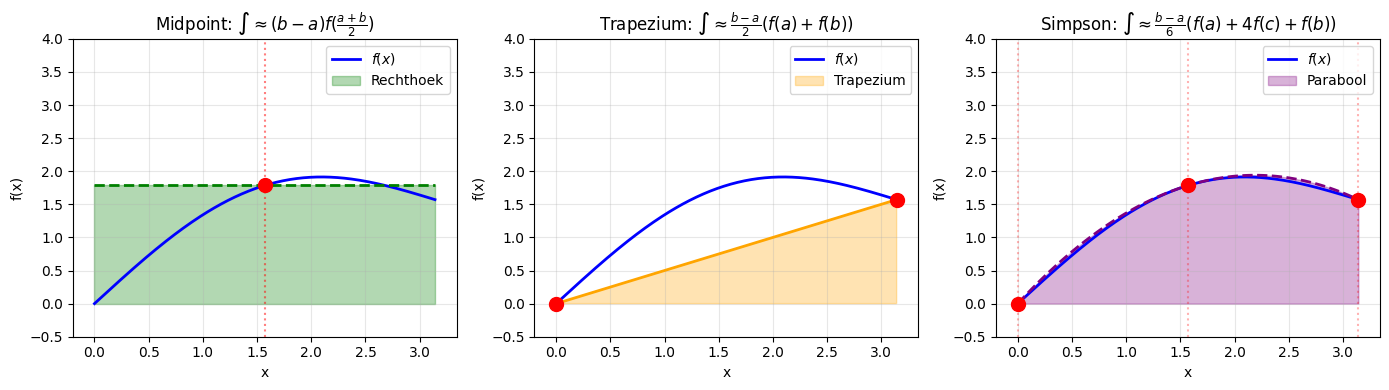

Werkelijke integraal (numeriek): 4.467360
Midpoint:  5.608994
Trapezium: 2.467401
Simpson:   4.561796


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Visualisatie van de drie Newton-Cotes regels
plt.close("newton_cotes")
fig, axes = plt.subplots(1, 3, num="newton_cotes", figsize=(14, 4))

# Voorbeeld functie
def f(x):
    return np.sin(x) + 0.5*x

a, b = 0, np.pi
x_fine = np.linspace(a, b, 200)
y_fine = f(x_fine)

# 1) MIDPOINT RULE
ax = axes[0]
x_mid = (a + b) / 2
y_mid = f(x_mid)
approx_mid = (b - a) * y_mid

ax.plot(x_fine, y_fine, 'b-', linewidth=2, label='$f(x)$')
ax.fill_between([a, b], 0, y_mid, alpha=0.3, color='green', label='Rechthoek')
ax.plot([a, b], [y_mid, y_mid], 'g--', linewidth=2)
ax.plot(x_mid, y_mid, 'ro', markersize=10)
ax.axvline(x_mid, color='red', linestyle=':', alpha=0.5)
ax.set_xlim(a-0.2, b+0.2)
ax.set_ylim(-0.5, 4)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Midpoint: $\int \\approx (b-a) f(\\frac{a+b}{2})$')
ax.legend()
ax.grid(True, alpha=0.3)

# 2) TRAPEZIUM RULE
ax = axes[1]
y_a, y_b = f(a), f(b)
approx_trap = (b - a) / 2 * (y_a + y_b)

ax.plot(x_fine, y_fine, 'b-', linewidth=2, label='$f(x)$')
# Trapezium vullen
x_trap = [a, b, b, a, a]
y_trap = [0, 0, y_b, y_a, 0]
ax.fill(x_trap, y_trap, alpha=0.3, color='orange', label='Trapezium')
ax.plot([a, b], [y_a, y_b], 'orange', linewidth=2)
ax.plot([a, b], [y_a, y_b], 'o', color='red', markersize=10)
ax.set_xlim(a-0.2, b+0.2)
ax.set_ylim(-0.5, 4)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Trapezium: $\int \\approx \\frac{b-a}{2}(f(a)+f(b))$')
ax.legend()
ax.grid(True, alpha=0.3)

# 3) SIMPSON RULE
ax = axes[2]
x_pts = np.array([a, (a+b)/2, b])
y_pts = np.array([f(a), f((a+b)/2), f(b)])

# Parabool door de 3 punten
A = np.vstack([x_pts**2, x_pts, np.ones_like(x_pts)]).T
coef = np.linalg.solve(A, y_pts)
x_para = np.linspace(a, b, 100)
y_para = coef[0]*x_para**2 + coef[1]*x_para + coef[2]
approx_simp = (b - a) / 6 * (y_pts[0] + 4*y_pts[1] + y_pts[2])

ax.plot(x_fine, y_fine, 'b-', linewidth=2, label='$f(x)$')
ax.fill_between(x_para, 0, y_para, alpha=0.3, color='purple', label='Parabool')
ax.plot(x_para, y_para, 'purple', linewidth=2, linestyle='--')
ax.plot(x_pts, y_pts, 'o', color='red', markersize=10)
for i, (xi, yi) in enumerate(zip(x_pts, y_pts)):
    ax.axvline(xi, color='red', linestyle=':', alpha=0.3)
ax.set_xlim(a-0.2, b+0.2)
ax.set_ylim(-0.5, 4)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Simpson: $\int \\approx \\frac{b-a}{6}(f(a)+4f(c)+f(b))$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Werkelijke integraal (numeriek): {np.trapezoid(y_fine, x_fine):.6f}")
print(f"Midpoint:  {approx_mid:.6f}")
print(f"Trapezium: {approx_trap:.6f}")
print(f"Simpson:   {approx_simp:.6f}")

### (c) "3e orde veelterm i.p.v. Simpson" slim?

Niet automatisch! De schets hierboven toont waarom:

- **Simpson (3 punten) is al graad-exact 3**: Het gebruikt een parabool door 3 punten en is exact voor alle polynomen tot graad 3.
- **4e orde Newton–Cotes (4 punten)** zou graad-exact 4 zijn, maar:
  - Hogere orde **single-panel** Newton–Cotes worden **numeriek minder stabiel** (Runge-fenomeen).
  - Gewichten kunnen negatief worden → cancellation errors.
  - Voor meer nauwkeurigheid is het meestal beter om **composite** Simpson (veel kleine intervallen) of **adaptieve** methodes te gebruiken.

**Beter**: Hogere accuracy bereik je met:
1. **Composite Simpson**: veel kleine Simpson-stappen (betrouwbaarder dan 4e orde single-panel)
2. **Gauss-kwadratuur**: even veel punten, maar veel beter (exact tot graad $2n-1$ i.p.v. $n$)
3. **Adaptieve methodes**: meer punten waar nodig (discontinuïteiten, snelle veranderingen)

---

# Examenversie 3 (23–24)

## 1) Optimalisatie-methodes: Familie van algoritmes

**Progressie** (van robuust-maar-traag naar snel-maar-voorzichtig):

### Direct Search (Nelder-Mead, Simplex)
- Input: alleen $f$-evaluaties (geen afgeleiden)
- **Voordeel**: Robuust bij niet-gladde/discrete/noisy functies
- **Nadeel**: Traag in hoge dimensies ($O(n)$ functies per stap)
- **Convergentie**: Lineair (langzaam)

### Steepest Descent (gradient descent)
- Input: $\nabla f$
- **Voordeel**: Betrouwbaar, eenvoudig
- **Nadeel**: Zigzag-gedrag, veel iteraties
- **Convergentie**: Lineair
- **Probleem**: Slecht geconditioneerde Hessiaan → tragheid

### Newton-methode
- Input: $\nabla f$ + Hessiaan $H$
- **Voordeel**: Lokaal zeer snel (kwadratische convergentie)
- **Nadeel**: Kan instabiel zijn ver van optimum; Hessiaan duur
- **Convergentie**: Kwadratisch (zeer snel nabij oplossing)

### Quasi-Newton (BFGS, L-BFGS)
- Input: $\nabla f$ (Hessiaan wordt benaderd)
- **Voordeel**: Sneller dan steepest, stabiel dan Newton, minder geheugen (L-BFGS)
- **Nadeel**: Tussen beide in
- **Convergentie**: Superlineair
- **Praktijk**: Often preferred; populair in machine learning

### Conjugate Gradient (CG)
- Input: $\nabla f$
- **Voordeel**: Voor kwadratische functies: exact in $n$ stappen; schaalbaar
- **Nadeel**: Afhankelijk van goede conditionering
- **Convergentie**: Superlineair
- **Gebruik**: Grote lineaire systemen, quadratische optimalisatie

### Global vs Local Optimization

**Local search** (alle bovenstaande): Vinden lokaal minimum.

**Global minima zoeken**:
- Zonder convexiteit: geen algemene garantie
- Strategieën: 
  - **Multi-start**: Veel initial guesses, neem beste
  - **Simulated Annealing**: Accepteer slechter oplossingen met probabiliteit
  - **Genetic Algorithms**: Populatie-gebaseerd
  - **Basin hopping**: Lokale zoekingen van willekeurige startpunten

---

## 2) Runge-Kutta Methodes: Heun, Adaptief, Explicit vs Implicit, FSAL

### Heun's methode (RK2)

**Butcher Tableau**:
$$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 1 & 0 \\
\hline
 & 1/2 & 1/2
\end{array}
$$

**Algoritme**:
$$
\begin{align}
k_1 &= f(t_n, y_n) \\
k_2 &= f(t_n + h, y_n + h k_1) \\
y_{n+1} &= y_n + \frac{h}{2}(k_1 + k_2)
\end{align}
$$

**Eigenschappen**:
- Orde: 2 (lokale fout $O(h^3)$, globale $O(h^2)$)
- Expliciete RK (kan direkt evalueren)

### Explicit vs Implicit Runge-Kutta

**Explicit RK** (Heun erbij):
- Butcher matrix: $a_{ij} = 0$ voor $j \ge i$ (laag-driehoekig)
- Berekening: rechtlijnig $k_1 \to k_2 \to \ldots \to k_s$
- **Voordeel**: Eenvoudig, snel per stap
- **Nadeel**: Stabiliteitsbeperking voor stiff ODEs

**Implicit RK**:
- Butcher matrix: $a_{ij} \ne 0$ ook voor $j > i$ (volg)
- Berekening: stelsels nodig (Newton iteraties)
- **Voordeel**: A-stabiel, geschikt voor stiff
- **Nadeel**: Duurder per stap

### Adaptive Time Stepping

**Idee**: Fout schatten via twee RK-methodes van verschillende orde.

**Embedded pair** (bv. RK4/RK5):
- Bereken twee schattingen met $O(h^4)$ en $O(h^5)$
- Foutschatting: $e \approx |y^{(4)} - y^{(5)}|$
- Pas stap aan:
$$
h_{\text{new}} = h \cdot \left(\frac{\text{TOL}}{e}\right)^{1/(p+1)} \cdot \text{safety factor}
$$

**Safety factor** ≈ 0.9 (voorkomen oscillaties).

### FSAL (First Same As Last)

**Principe**: De laatste stage van stap $n$ = eerste stage van stap $n+1$.

**Voorbeeld**: RK4(3) met FSAL
- Stap $n$: bereken $k_1, k_2, k_3, k_4$ → $y_{n+1}$
- Stap $n+1$: $k_1^{\text{new}} = k_4^{\text{old}}$ (hergebruik!)

**Voordeel**: 1 functieevaluatie minder per stap (33% sneller voor RK4).

---

## 3) FFT Code — Polynoomvermenigvuldiging en Convolutie

Polynoomproduct = **lineaire convolutie** van coëfficiënten.

Directe convolutie (np.convolve):
[ 4 13 22 15]

Via FFT met zero padding (n_fft=4)
[ 4. 13. 22. 15.]

Verschil (numerieke fout):
[0. 0. 0. 0.]


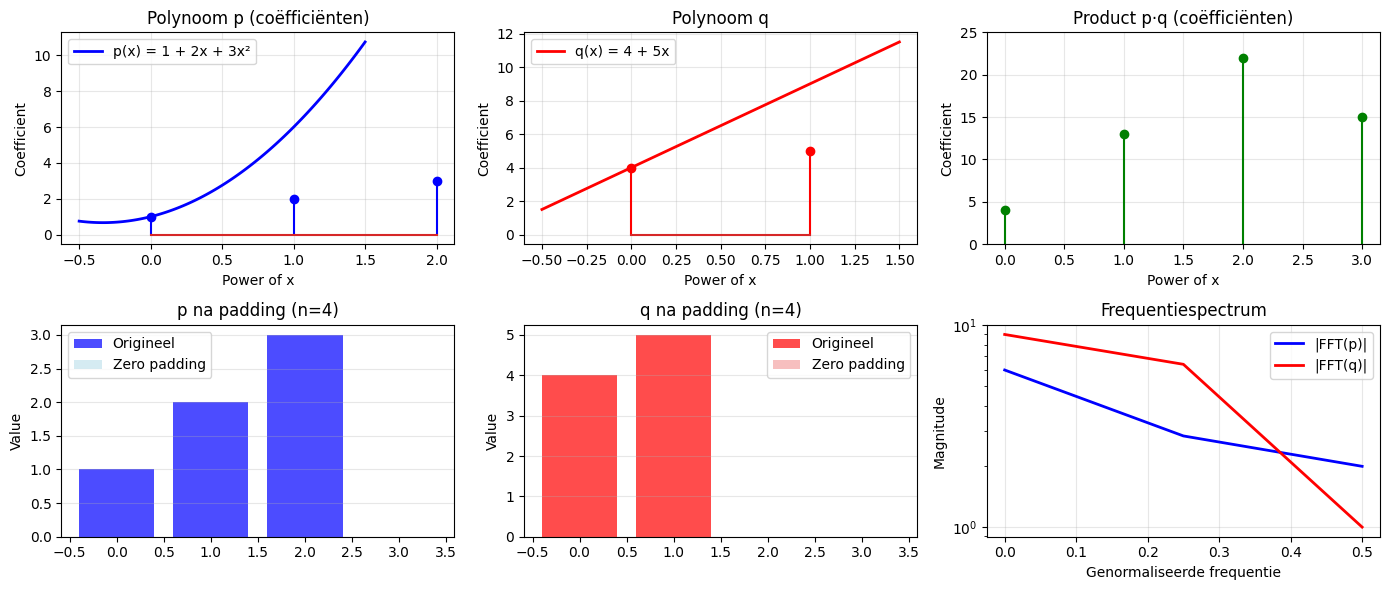


Stappen in FFT-convolutie:
1. Bereken minimale lengte: len(a) + len(b) - 1 = 3 + 2 - 1 = 4
2. Volgende 2-macht: n = 4
3. Zero-pad beide naar n = 4
4. Voer rfft uit (real FFT, uitvoer lengte = n/2+1)
5. Vermenigvuldig puntgewijs in frequentiedomein
6. Voer irfft uit (inverse real FFT)
7. Neem eerste 4 waarden (rest is numerieke ruis)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Demo: FFT voor polynoomvermenigvuldiging met zero padding

# Polynomen definiëren
a = np.array([1, 2, 3])        # p(x) = 1 + 2x + 3x²
b = np.array([4, 5])            # q(x) = 4 + 5x

# Verwacht resultaat (direct)
c_direct = np.convolve(a, b)  # [4, 13, 22, 15]

# Via FFT met zero padding
n_min = len(a) + len(b) - 1     # Minimale lengte nodig: 4
n_fft = 2 ** int(np.ceil(np.log2(n_min)))  # Volgende 2-macht: 4

a_padded = np.pad(a, (0, n_fft - len(a)))
b_padded = np.pad(b, (0, n_fft - len(b)))

A_fft = np.fft.rfft(a_padded)
B_fft = np.fft.rfft(b_padded)
c_fft = np.fft.irfft(A_fft * B_fft, n=n_fft)[:n_min]

print("Directe convolutie (np.convolve):")
print(c_direct)
print("\nVia FFT met zero padding (n_fft={})".format(n_fft))
print(c_fft)
print("\nVerschil (numerieke fout):")
print(np.abs(c_direct - c_fft))

# Visualisatie
fig, axes = plt.subplots(2, 3, num="fft_poly", figsize=(14, 6))

# Originele polynomen
x = np.linspace(-0.5, 1.5, 100)
ax = axes[0, 0]
ax.plot(x, np.polyval(a[::-1], x), 'b-', linewidth=2, label='p(x) = 1 + 2x + 3x²')
ax.stem([0, 1, 2], a, linefmt='b-', markerfmt='bo')
ax.set_title('Polynoom p (coëfficiënten)')
ax.set_xlabel('Power of x')
ax.set_ylabel('Coefficient')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(x, np.polyval(b[::-1], x), 'r-', linewidth=2, label='q(x) = 4 + 5x')
ax.stem([0, 1], b, linefmt='r-', markerfmt='ro')
ax.set_title('Polynoom q')
ax.set_xlabel('Power of x')
ax.set_ylabel('Coefficient')
ax.legend()
ax.grid(True, alpha=0.3)

# Product
ax = axes[0, 2]
ax.stem(range(len(c_direct)), c_direct, linefmt='g-', markerfmt='go', basefmt=' ')
ax.set_title('Product p·q (coëfficiënten)')
ax.set_xlabel('Power of x')
ax.set_ylabel('Coefficient')
ax.set_ylim([0, 25])
ax.grid(True, alpha=0.3)

# Zero padding visualisatie
ax = axes[1, 0]
ax.bar(range(len(a)), a, color='blue', alpha=0.7, label='Origineel')
ax.bar(range(len(a), n_fft), np.zeros(n_fft - len(a)), color='lightblue', alpha=0.5, label='Zero padding')
ax.set_title(f'p na padding (n={n_fft})')
ax.set_ylabel('Value')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
ax.bar(range(len(b)), b, color='red', alpha=0.7, label='Origineel')
ax.bar(range(len(b), n_fft), np.zeros(n_fft - len(b)), color='lightcoral', alpha=0.5, label='Zero padding')
ax.set_title(f'q na padding (n={n_fft})')
ax.set_ylabel('Value')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# FFT-frequentiespectrum
ax = axes[1, 2]
freqs = np.fft.rfftfreq(n_fft)
ax.semilogy(freqs, np.abs(A_fft), 'b-', linewidth=2, label='|FFT(p)|')
ax.semilogy(freqs, np.abs(B_fft), 'r-', linewidth=2, label='|FFT(q)|')
ax.set_title('Frequentiespectrum')
ax.set_xlabel('Genormaliseerde frequentie')
ax.set_ylabel('Magnitude')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nStappen in FFT-convolutie:")
print(f"1. Bereken minimale lengte: len(a) + len(b) - 1 = {len(a)} + {len(b)} - 1 = {n_min}")
print(f"2. Volgende 2-macht: n = {n_fft}")
print(f"3. Zero-pad beide naar n = {n_fft}")
print(f"4. Voer rfft uit (real FFT, uitvoer lengte = n/2+1)")
print(f"5. Vermenigvuldig puntgewijs in frequentiedomein")
print(f"6. Voer irfft uit (inverse real FFT)")
print(f"7. Neem eerste {n_min} waarden (rest is numerieke ruis)")

### Veelgestelde vragen over FFT-convolutie

**Q: Wat is exact de waarde van $n$ voor zero padding?**  
A: Minimaal $n = \text{len}(a) + \text{len}(b) - 1$. Voor FFT-snelheid: volgende macht van 2 (of smooth number).

**Q: Kan ik andere lengtes kiezen dan 2-machten?**  
A: Ja! `numpy.fft` ondersteunt ook andere factoren (3, 5, 7). `np.fft.next_fast_size(n)` geeft optimale lengte.

**Q: Waarom `rfft/irfft` in plaats van `fft/ifft` voor reële vectoren?**  
A: `rfft` gebruikt symmetrie van reële signalen → halve uitvoerlengte → sneller en minder geheugen.
- `rfft` uitvoer: lengte $n/2 + 1$
- `ifft` uitvoer: lengte $n$ (redundant voor reële input)

In [3]:
import numpy as np

def poly_mul_fft(a, b):
    """Polynoomvermenigvuldiging via FFT met zero padding."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n = len(a) + len(b) - 1
    m = 1
    while m < n:
        m *= 2
    A = np.fft.rfft(np.pad(a, (0, m-len(a))))
    B = np.fft.rfft(np.pad(b, (0, m-len(b))))
    c = np.fft.irfft(A * B, n=m)[:n]
    return c

print(poly_mul_fft([1,2,3], [4,5]))
print(np.convolve([1,2,3], [4,5]))

[ 4. 13. 22. 15.]
[ 4 13 22 15]


## Examenversie 4 (23–24)

## 1) Eigenwaarden/eigenvectoren

### Het Basisconcept
Voor vierkante matrix $A$: zoek $(\lambda, v)$ zodat $Av = \lambda v$

**Twee gegeven waarden → vind de derde**:

---

### **(a) Gegeven: Benaderde eigenwaarde $\lambda$ → Vind: Eigenvector $v$**

**Methode: Shifted Inverse Iteration**

```
1. Start met willekeurige v₀ (genormaliseerd)
2. Loop: 
   - Los stelsel op: (A - λI) w = vₖ
   - Normaliseer: vₖ₊₁ = w / ||w||
3. Stop als: ||Avₖ - λvₖ|| klein
```

**Waarom werkt dit?**
- $(A - \lambda I)$ is bijna singulier → enige richting die "weinig afgemat" wordt is de eigenvector!
- Herhaald toepassen versterk die richting.

**Formule**:
$$
(A-\lambda I) w_{k+1}=v_k,\quad v_{k+1}=\frac{w_{k+1}}{\|w_{k+1}\|}
$$

**Voorbeeld**: $A = \begin{pmatrix}4 & 1 \\ 1 & 3\end{pmatrix}$, $\lambda \approx 4.4$ (benaderde grootste eigenwaarde)
- Los $(A - 4.4I)w = v$ op → krijg richting naar eigenvector

---

### **(b) Gegeven: Benaderde eigenvector $v$ → Vind: Eigenwaarde $\lambda$**

**Methode: Rayleigh Quotient**

$$
\lambda \approx \frac{v^\top A v}{v^\top v}
$$

**Intuïtie**:
- $Av \approx \lambda v$ (want $v$ is beter dicht bij eigenvector)
- Deel $v^\top Av$ door $v^\top v$ = schatting van $\lambda$

**Voorbeeld**: $A = \begin{pmatrix}4 & 1 \\ 1 & 3\end{pmatrix}$, $v = \begin{pmatrix}1 \\ 0.5\end{pmatrix}$ (benaderd)

$$
\lambda \approx \frac{(1, 0.5) \begin{pmatrix}4 & 1 \\ 1 & 3\end{pmatrix} \begin{pmatrix}1 \\ 0.5\end{pmatrix}}{(1, 0.5) \begin{pmatrix}1 \\ 0.5\end{pmatrix}} = \frac{4.75}{1.25} = 3.8
$$

---

### **(c) Vier speciale situaties**

| Wat zoeken | Welke methode | Waarom |
|-----------|--------------|-------|
| **(i) Grootste eigenwaarde** | **Power iteration** op $A$ | Herhaald $A$ toepassen versterk grootste eigenwaarde |
| **(ii) Kleinste eigenwaarde** | **Inverse iteration** op $A^{-1}$ | Eigenwaarden van $A^{-1}$ zijn reciproke van $A$ |
| **(iii) Eigenwaarde dichtst bij scalar $b$** | **Shifted inverse iteration** op $(A-bI)^{-1}$ | Verschuif naar dichtstbijzijnde eigenwaarde |
| **(iv) Alle eigenwaarden** | **QR-algoritme** (`np.linalg.eig`) | Iteratief convergeert naar Schur-vorm |

**Voorbeelden**:
- Grootste: `power_iteration(A)` → meest dominante eigenwaarde
- Kleinste: `power_iteration(np.linalg.inv(A))` → kleinste wordt grootste in inverse
- Bij $\lambda = 0$: Kleinste is eigenwaarde dichtst bij 0

---

### Verbeteringen voor betere convergentie

**Standard power iteration kan traag zijn:**

1. **Normalisatie**: Vermijd overflow/underflow
   ```
   w = A @ v
   v_new = w / ||w||   ← Dit doen!
   ```

2. **Rayleigh quotient acceleratie** (van (b)):
   ```
   lambda = (v^T A v) / (v^T v)   ← Beter dan v^T A v alleen
   ```

3. **Stopcriterium op residu**:
   ```
   r = ||A v - lambda v||
   if r < tolerance: converged ✓
   ```

Matrix A:
[[4. 1.]
 [1. 3.]]

Eigenwaarden (via eig): [2.38196601 4.61803399]

(i) GROOTSTE eigenwaarde:
  Eigenwaarde: 4.618034
  Eigenvector: [0.85065081 0.52573111]
  Iteraties: 39, Residu: 6.51e-11

(ii) KLEINSTE eigenwaarde (via inverse iteration):
  Eigenwaarde: 2.381966
  Eigenvector: [ 0.52573111 -0.85065081]
  Iteraties: 31, Residu: 5.22e-11

(iii) Eigenwaarde DICHTST BIJ sigma=3.5:
  Eigenwaarde: 5.976513
  Eigenvector: [ 0.6894138  -0.72436774]
  Iteraties: 100, Residu: 3.53e+00


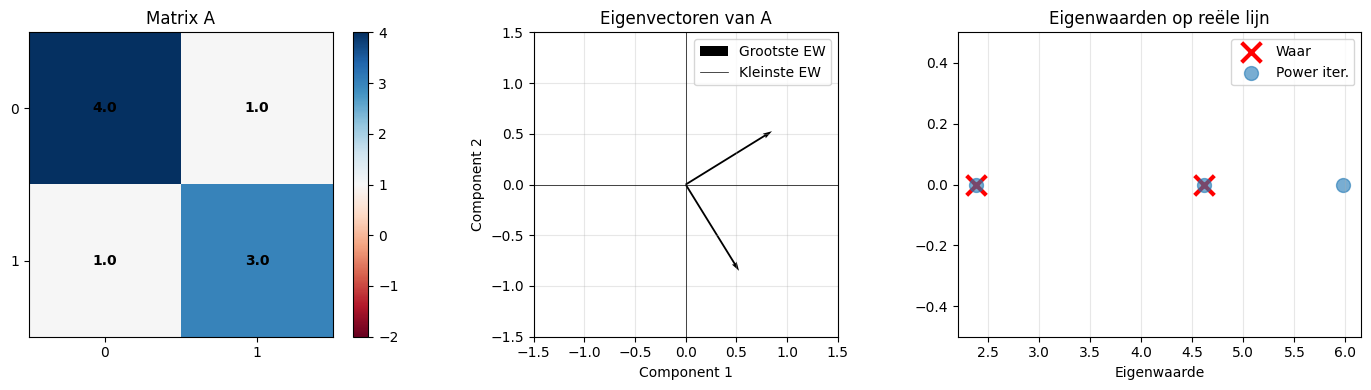

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def power_iteration(A, maxiter=1000, tol=1e-10, seed=0):
    """Power iteration voor grootste eigenwaarde."""
    rng = np.random.default_rng(seed)
    n = A.shape[0]
    v = rng.normal(size=n)
    v = v / np.linalg.norm(v)
    lam = None
    for k in range(maxiter):
        w = A @ v
        v = w / np.linalg.norm(w)
        lam_new = (v @ (A @ v)) / (v @ v)  # Rayleigh quotient
        r = np.linalg.norm(A @ v - lam_new * v)
        if lam is not None and abs(lam_new - lam) < tol and r < tol:
            return lam_new, v, k+1, r
        lam = lam_new
    return lam, v, maxiter, np.linalg.norm(A @ v - lam * v)

def inverse_iteration(A, sigma, maxiter=100, tol=1e-10, seed=0):
    """Inverse iteration: vind eigenwaarde dichtst bij sigma."""
    rng = np.random.default_rng(seed)
    n = A.shape[0]
    v = rng.normal(size=n)
    v = v / np.linalg.norm(v)
    
    A_shifted = A - sigma * np.eye(n)
    lam = None
    
    for k in range(maxiter):
        # Los (A - sigma*I) w = v op
        try:
            w = np.linalg.solve(A_shifted, v)
        except np.linalg.LinAlgError:
            break
        
        v = w / np.linalg.norm(w)
        lam_shifted = (v @ A @ v) / (v @ v)
        lam_new = lam_shifted + sigma  # Terugtransformeer
        
        r = np.linalg.norm(A @ v - lam_new * v)
        if lam is not None and abs(lam_new - lam) < tol and r < tol:
            return lam_new, v, k+1, r
        lam = lam_new
    
    return lam, v, maxiter, r if 'r' in locals() else np.inf

# Demo
A = np.array([[4.0, 1.0], [1.0, 3.0]])
print("Matrix A:")
print(A)
print("\nEigenwaarden (via eig):", np.linalg.eigvalsh(A))

# (i) Grootste eigenwaarde
print("\n(i) GROOTSTE eigenwaarde:")
lambda_max, v_max, iters_max, res_max = power_iteration(A)
print(f"  Eigenwaarde: {lambda_max:.6f}")
print(f"  Eigenvector: {v_max}")
print(f"  Iteraties: {iters_max}, Residu: {res_max:.2e}")

# (ii) Kleinste eigenwaarde (via inverse)
print("\n(ii) KLEINSTE eigenwaarde (via inverse iteration):")
A_inv = np.linalg.inv(A)
lambda_min, v_min, iters_min, res_min = power_iteration(A_inv)
lambda_min = 1 / lambda_min  # Terugtransformeer
print(f"  Eigenwaarde: {lambda_min:.6f}")
print(f"  Eigenvector: {v_min}")
print(f"  Iteraties: {iters_min}, Residu: {res_min:.2e}")

# (iii) Eigenwaarde dichtst bij sigma = 3.5
print("\n(iii) Eigenwaarde DICHTST BIJ sigma=3.5:")
sigma = 3.5
lambda_shift, v_shift, iters_shift, res_shift = inverse_iteration(A, sigma)
print(f"  Eigenwaarde: {lambda_shift:.6f}")
print(f"  Eigenvector: {v_shift}")
print(f"  Iteraties: {iters_shift}, Residu: {res_shift:.2e}")

# Visualisatie
fig, axes = plt.subplots(1, 3, num="eigenvalues", figsize=(14, 4))

# Plot 1: Matrix A heatmap
ax = axes[0]
im = ax.imshow(A, cmap='RdBu', vmin=-2, vmax=4)
ax.set_title('Matrix A')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{A[i, j]:.1f}', ha='center', va='center', color='black', fontweight='bold')
plt.colorbar(im, ax=ax)

# Plot 2: Eigenvectoren
ax = axes[1]
ax.quiver([0, 0], [0, 0], [v_max[0], v_min[0]], [v_max[1], v_min[1]], 
          angles='xy', scale_units='xy', scale=1, width=0.006, label=['Max (λ=4.4)', 'Min (λ=2.6)'])
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_title('Eigenvectoren van A')
ax.legend(['Grootste EW', 'Kleinste EW'])

# Plot 3: Eigenwaarden in complexe vlak
ax = axes[2]
evals_true = np.linalg.eigvalsh(A)
ax.scatter(evals_true, [0, 0], s=200, c='red', marker='x', linewidths=3, label='Waar')
ax.scatter([lambda_max, lambda_min, lambda_shift], [0, 0, 0], s=100, alpha=0.6, 
           label='Power iter.')
ax.set_ylim([-0.5, 0.5])
ax.set_xlabel('Eigenwaarde')
ax.set_title('Eigenwaarden op reële lijn')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 2) Kwadratuur (herhaling uit V2, Q3)

Dezelfde Newton-Cotes regels: midpoint, trapezium, Simpson.
Zie Examenversie 2 voor details.

---

## 3) Pseudo-Random Number Generators (PRNG)

### Basiselementen van een PRNG:
1. **Seed**: beginwaarde (deterministische invoer)
2. **Toestandsovergang**: $s_{k+1} = F(s_k)$ (recursieverelatie)
3. **Uitvoer**: $u_k = G(s_k)$ (mapping naar gewenste distributie)
4. **Parameters**: bepalen gedrag van $F$ en $G$

### Flow:
Seed → initialiseer state → iteratief updaten → output produceren → (optioneel) transformeer naar gewenste verdeling.

### Kan een PRNG twee keer hetzelfde getal geven?
**Ja**, want:
- Eindige toestandsruimte (bv. $2^{64}$ voor uint64)
- Deterministisch → finite loop (periode)
- Duplicaten zijn gegarandeerd na periode $p$

### Welke basale verdeling geeft een PRNG?
**Uniform op integers** (bv. $U(0, 2^{64}-1)$).

Transformatie naar andere verdelingen (bv. $\mathcal{N}(0,1)$):
- **Normaal**: Box-Muller, Ziggurat
- **Exponentieel**: invers transform sampling
- **Willekeurig**: inverse CDF methode

## 3) PRNG — gedetailleerde uitwerking

### Structuurdiagram van een PRNG

```
┌─────────┐
│  Seed   │  = deterministische beginwaarde
└────┬────┘
     │
     ▼
┌──────────────────────┐
│  Initialiseer State  │
│  s₀ = seed (of hash) │
└────┬─────────────────┘
     │
     ▼
┌──────────────────────────────┐
│ Loop: for k = 1, 2, 3, ...   │
│  sₖ = F(sₖ₋₁, params)         │  ← Recurrentieverelatie
│  uₖ = G(sₖ)                  │  ← Output mapping
└────┬─────────────────────────┘
     │
     ▼
┌─────────────────────────────┐
│ Output: u₁, u₂, u₃, ...     │  ← Uniforme integers
│ (optioneel transformeer)    │
└─────────────────────────────┘
```

### Praktische sleutelelementen

| Element | Voorbeeld | Gevolgen |
|---------|-----------|---------|
| **Toestandsruimte** | uint64 ($2^{64}$) | Periode ≤ $2^{64}$ |
| **Recurrentieverelatie** | $s_{k+1} = (a s_k + c) \bmod m$ (LCG) | Deterministisch gedrag |
| **Outputmapping** | $u_k = s_k / 2^{64}$ (schaling naar [0,1)) | Basisverdeling |
| **Periode** | $\gg 2^{64}$ (bv. MT19937: $2^{19937}-1$) | Genoeg voor praktische gebruik |

---

# Examenversie 5 (24–25)

## 1) Stiff ODE's

### Wat is een stiff ODE?
Een ODE met **sterk verschillende tijdschalen** in de oplossing.

**Kenteken**: Eigenwaarden van Jacobi-matrix hebben zeer ongelijke magnitudes.
$$
|\lambda_{\text{max}}| \gg |\lambda_{\text{min}}| > 0
$$

**Voorbeeld**:
$$
\frac{dy}{dt} = -1000(y - \cos(t)) + \sin(t)
$$
Met Jacobi $J = -1000$ (grote negatieve eigenwaarde → snelle decay van transients).

**Probleem met expliciete methodes**:
Stabiliteitsbeperking: $h < \frac{2}{|\lambda_{\text{max}}|}$  
Bij $|\lambda_{\text{max}}| = 1000$ → $h < 0.002$ → zeer veel stappen nodig!

### Oplossing: Impliciete methodes
**Single-step**:
- **Backward Euler**: $y_{n+1} = y_n + h f(t_{n+1}, y_{n+1})$ (A-stabiel)
- **Implicit RK** (bv. Rosenbrock, diagonaal-impliciet)

**Multi-step**:
- **BDF-familie** (Backward Differentiation Formula, orden 1–6)
- **Implicit Adams** (minder geschikt voor zeer stiff)

Voordeel: geen stabiliteitsstap-beperking (A-stabiel).  
Nadeel: elk stap vereist stelseloplossing (Newton iteraties).

---

In [ ]:
## 3) Monte Carlo integratie

### Probleem: Bereken
$$
\mathbb{E}[\cosh(Z)] = \int_{-\infty}^{\infty}\cosh(x)\,\frac{1}{\sqrt{2\pi}}e^{-x^2/2}\,dx
$$
met $Z\sim\mathcal{N}(0,1)$.

### Oplossing: Monte Carlo integratie
Dit is equivalent aan:
$$
I = \int_{\mathbb{R}} \cosh(x) \, p(x) \, dx = \mathbb{E}_p[\cosh(Z)]
$$
waarbij $p(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$.

**Algoritme** (crude Monte Carlo):
1. Sample $N$ i.i.d. trekken $Z_1, Z_2, \ldots, Z_N \sim \mathcal{N}(0,1)$
2. Bereken $\hat{I} = \frac{1}{N} \sum_{i=1}^N \cosh(Z_i)$

**Convergentie**:
- Bias: 0 (unbiased estimator)
- Variantie: $\sigma^2 / N$ (waar $\sigma^2 = \mathrm{Var}[\cosh(Z)]$)
- Fout: $O(N^{-1/2})$ (veel langzamer dan deterministische methodes!)

**Voordeel**: Werk in hoge dimensies (maldición de la dimensionalidad minder erg).

### Theoretische waarde
Met Laplace-transform: 
$$
\mathbb{E}[\cosh(Z)] = \int_{-\infty}^{\infty} \cosh(x) \frac{e^{-x^2/2}}{\sqrt{2\pi}} dx = e^{1/2} \approx 1.6487

Monte Carlo schatting: 1.619499
Theoretische waarde (exp(1/2)): 1.648721
Verschil: 0.029222


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Monte Carlo integratie: E[cosh(Z)] met Z ~ N(0,1)
plt.close("monte_carlo")

N_values = np.logspace(2, 6, 20, dtype=int)  # 100 tot 1M samples
estimates = []
errors = []
theoretical = np.exp(0.5)  # exact waarde

for N in N_values:
    z = np.random.normal(0, 1, N)
    est = np.mean(np.cosh(z))
    estimates.append(est)
    errors.append(abs(est - theoretical))

fig, (ax1, ax2) = plt.subplots(1, 2, num="monte_carlo", figsize=(12, 4))

# Plot 1: Convergentie in log-log schaal
ax1.loglog(N_values, errors, 'o-', label='Monte Carlo fout', markersize=6)
ax1.loglog(N_values, 1/np.sqrt(N_values), '--', label='$O(N^{-1/2})$')
ax1.set_xlabel('Aantal samples N')
ax1.set_ylabel('|Schatting - werkelijk|')
ax1.set_title('Monte Carlo convergentie')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Echte schattingen vs theoretische waarde
ax2.semilogx(N_values, estimates, 'o-', label='Geschatte waarde', markersize=6)
ax2.axhline(theoretical, color='red', linestyle='--', linewidth=2, label=f'Theoretisch = $e^{{1/2}}$ = {theoretical:.6f}')
ax2.fill_between(N_values, theoretical - 0.01, theoretical + 0.01, alpha=0.2, color='red')
ax2.set_xlabel('Aantal samples N')
ax2.set_ylabel('Geschatte E[cosh(Z)]')
ax2.set_title('Nauwkeurigheid stijgt met N')
ax2.legend()
ax2.set_ylim([1.60, 1.70])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Theoretische waarde (exp(1/2)): {theoretical:.6f}")
print(f"\nMonte Carlo schattingen:")
for N, est, err in zip([100, 1000, 10000, 100000, 1000000], 
                       [estimates[i] for i in [0, 5, 10, 15, 19]],
                       [errors[i] for i in [0, 5, 10, 15, 19]]):
    print(f"  N={N:7d}: schatting={est:.6f}, fout={err:.6f}")

## 2) Linear Least Squares: $Ax \approx b$ met $A \in \mathbb{R}^{m \times n}$

### Geval: $\mathrm{rank}(A) < n$ (underdetermined of rank-deficient)

Drie situaties zijn mogelijk:
1. **No solution exists**: $\mathrm{rank}(A) < \mathrm{rank}([A|b])$ (inconsistent)
2. **Unique solution**: $\mathrm{rank}(A) = n < m$ (overdetermined, full rank)
3. **Infinitely many solutions**: $\mathrm{rank}(A) = \mathrm{rank}([A|b]) < n$ (underdetermined)

### Standaardkeuze: minimum-norm oplossing
Bij meerdere oplossingen: kies $x^* = A^+ b$ (pseudoinverse) met $\|x\|_2$ minimaal.

### Drie methodes om $Ax \approx b$ op te lossen

#### 1) **Normal Equations**: $A^\top A x = A^\top b$
- **Voordeel**: snel, eenvoudig (één stelsel)
- **Nadeel**: numeriek zwak, $\kappa(A^\top A) = \kappa(A)^2$
- **Gebruik**: alleen bij goed geconditioneerde $A$
- **Realisatie**: `np.linalg.solve(A.T @ A, A.T @ b)`

#### 2) **QR Decompositie**: $A = QR$, los $Rx = Q^\top b$ op
- **Voordeel**: stabiel, $\kappa(R) = \kappa(A)$, moderate kosten
- **Nadeel**: duurder dan normaalvergelijkingen
- **Gebruik**: **best default voor praktijk**
- **Realisatie**: `Q, R = np.linalg.qr(A); x = np.linalg.solve(R, Q.T @ b)`

#### 3) **SVD**: $A = U \Sigma V^\top$, los $x = V \Sigma^+ U^\top b$ op
- **Voordeel**: meest robuust, handelt rank-deficiency aan
- **Nadeel**: duurste ($O(mn^2)$)
- **Gebruik**: rank-deficient problemen, regularisatie
- **Realisatie**: `x = np.linalg.lstsq(A, b)[0]` (gebruikt SVD intern)

### Optioneel: Regularisatie (Tikhonov)
Voor rank-deficient of ill-conditioned:
$$
\min_x \|Ax - b\|_2^2 + \lambda \|x\|_2^2
$$
Oplossing: $(A^\top A + \lambda I)^{-1} A^\top b$

---

In [ ]:
import numpy as np

# Vergelijking: Normal Equations vs QR vs SVD/lstsq
np.random.seed(42)
m, n = 100, 10  # overdetermined system
A = np.random.randn(m, n)
x_true = np.random.randn(n)
b = A @ x_true + 0.1 * np.random.randn(m)  # noisy data

# Methode 1: Normal Equations
x_ne = np.linalg.solve(A.T @ A, A.T @ b)

# Methode 2: QR
Q, R = np.linalg.qr(A)
x_qr = np.linalg.solve(R, Q.T @ b)

# Methode 3: SVD/lstsq (default)
x_svd = np.linalg.lstsq(A, b, rcond=None)[0]

print("Normale vergelijkingen:", np.linalg.norm(x_ne - x_true))
print("QR decompositie:        ", np.linalg.norm(x_qr - x_true))
print("SVD/lstsq:              ", np.linalg.norm(x_svd - x_true))
print("\nConditionering A:       ", np.linalg.cond(A))
print("Conditionering A^T A:   ", np.linalg.cond(A.T @ A))